In [6]:
# build_per_seed_ratios.py  (REPLACEMENT)
import pandas as pd
import glob, os, re
import numpy as np

CASE_ROOTS = {
    "Case 1": "../paper2-3scenario-case1/e1",   # folder containing e1detectors_*.csv for case 1
    "Case 2": "../paper2-3scenario-case2/e1",
    "Case 3": "../paper2-3scenario-case3/e1",
}

def mean_speed_aggregation(series):
    pos = series[series > 0]
    neg = series[series < 0]
    if len(pos) > 0 and len(neg) == 0:
        return pos.mean()
    elif len(pos) == 0 and len(neg) > 0:
        return neg.mean()
    elif len(pos) > 0 and len(neg) > 0:
        return pos.mean()
    else:
        return 0.0

def compute_spr(row, speed_limit_baseline=112.654):
    base_speed   = row["interval_harmonicMeanSpeed_base"]
    attack_speed = row["interval_harmonicMeanSpeed_attack"]
    if base_speed < 0 and attack_speed > 0:
        return round(attack_speed / speed_limit_baseline, 2)
    elif base_speed < 0 and attack_speed < 0:
        return -1
    elif base_speed > 0 and attack_speed < 0:
        return -2
    else:
        if base_speed == 0:
            return -999
        return round(attack_speed / base_speed, 2)

def compute_fr(row):
    base_flow   = row["interval_flow_base"]
    attack_flow = row["interval_flow_attack"]
    if base_flow == 0 and attack_flow > 0:
        return -1
    elif base_flow > 0 and attack_flow == 0:
        return 0
    elif base_flow == 0 and attack_flow == 0:
        return 1
    else:
        return round(attack_flow / base_flow, 2)

def parse_link_pos(interval_id):
    parts = str(interval_id).split("_")
    link = parts[0]
    pos = int(re.sub(r"[^\d]+", "", parts[-1])) if parts else 0
    return link, pos

def load_one_csv(path, scenario, seed):
    df = pd.read_csv(path, sep=";")
    df["scenario"] = scenario
    df["seed"] = int(seed)
    link_pos = df["interval_id"].apply(lambda x: pd.Series(parse_link_pos(x)))
    link_pos.columns = ["link", "pos"]
    df = pd.concat([df, link_pos], axis=1)
    return df

def collect_case(case_root):
    files = glob.glob(os.path.join(case_root, "e1detectors_*.csv"))
    attack, base = [], []
    for fp in files:
        name = os.path.basename(fp).replace(".csv","")
        parts = name.split("_")  # ['e1detectors','attack','989']
        if len(parts) < 3: 
            continue
        scenario, seed = parts[1], parts[2]
        if scenario not in ("attack","base"):
            continue
        df = load_one_csv(fp, scenario, seed)
        (attack if scenario=="attack" else base).append(df)
    if not attack or not base:
        return None
    return pd.concat(attack, ignore_index=True), pd.concat(base, ignore_index=True)

def collapse_lanes(df):
    # Collapse lanes: (seed, time, link, pos) -> flow=sum, speed=custom aggregator
    return (df.groupby(["seed","interval_begin","link","pos"], as_index=False)
              .agg(interval_flow=("interval_flow","sum"),
                   interval_harmonicMeanSpeed=("interval_harmonicMeanSpeed", mean_speed_aggregation)))

def build_ratios_for_case(case_label, case_root, out_csv):
    res = collect_case(case_root)
    if res is None:
        print(f"[WARN] No data for {case_label} in {case_root}")
        return
    attack_df_raw, base_df_raw = res

    # FIX A: collapse lanes BEFORE merge
    attack_df = collapse_lanes(attack_df_raw)
    base_df   = collapse_lanes(base_df_raw)

    merged = pd.merge(
        attack_df, base_df,
        on=["seed","interval_begin","link","pos"],
        suffixes=("_attack","_base"),
        how="inner"
    )

    merged["SPR"] = merged.apply(compute_spr, axis=1)
    merged["FR"]  = merged.apply(compute_fr, axis=1)

    # FIX B: drop sentinel codes from SR/FR (keep valid 0..∞ values)
    merged.loc[merged["SPR"] < 0, "SPR"] = np.nan
    merged.loc[merged["FR"]  < 0, "FR"]  = np.nan

    keep = [
        "seed","interval_begin","link","pos",
        "interval_harmonicMeanSpeed_attack","interval_harmonicMeanSpeed_base",
        "interval_flow_attack","interval_flow_base",
        "SPR","FR"
    ]
    merged = merged[keep].sort_values(["seed","interval_begin","link","pos"]).reset_index(drop=True)
    os.makedirs("bands_out", exist_ok=True)
    merged.to_csv(out_csv, index=False)
    print(f"[OK] {case_label}: wrote per-seed ratios -> {out_csv}")

if __name__ == "__main__":
    os.makedirs("bands_out", exist_ok=True)
    build_ratios_for_case("Case 1", CASE_ROOTS["Case 1"], "bands_out/case1_per_seed_ratios.csv")
    build_ratios_for_case("Case 2", CASE_ROOTS["Case 2"], "bands_out/case2_per_seed_ratios.csv")
    build_ratios_for_case("Case 3", CASE_ROOTS["Case 3"], "bands_out/case3_per_seed_ratios.csv")


[OK] Case 1: wrote per-seed ratios -> bands_out/case1_per_seed_ratios.csv
[OK] Case 2: wrote per-seed ratios -> bands_out/case2_per_seed_ratios.csv
[OK] Case 3: wrote per-seed ratios -> bands_out/case3_per_seed_ratios.csv


In [10]:
# build_bands_from_per_seed.py  (REPLACEMENT)
import pandas as pd
import numpy as np
import os

IN_FILES = [
    ("Case 1", "bands_out/case1_per_seed_ratios.csv"),
    ("Case 2", "bands_out/case2_per_seed_ratios.csv"),
    ("Case 3", "bands_out/case3_per_seed_ratios.csv"),
]

DIST_START = 0
DIST_END   = 3000
TIME_START = 55200
TIME_END   = 58800

def nanq(x, q):
    x = np.asarray(x, dtype=float)
    return np.nanquantile(x, q)

def build_bands(case_label, path, out_csv):
    df = pd.read_csv(path)

    # same filters as your plotting
    df = df[(df["pos"] >= DIST_START) & (df["pos"] <= DIST_END) &
            (df["interval_begin"] >= TIME_START) & (df["interval_begin"] <= TIME_END)]

    # mean across space per seed per time (ignore NaNs)
    agg = (df.groupby(["seed","interval_begin"], as_index=False)
             .agg(SPR=("SPR", lambda s: np.nanmean(s)),
                  FR =("FR",  lambda s: np.nanmean(s))))

    # mean + percentile across seeds per time (ignore NaNs)
    bands = (agg.groupby("interval_begin")
               .agg(SPR_mean=("SPR", lambda s: np.nanmean(s)),
                    SPR_p05 =("SPR", lambda s: nanq(s, 0.05)),
                    SPR_p95 =("SPR", lambda s: nanq(s, 0.95)),
                    FR_mean =("FR",  lambda s: np.nanmean(s)),
                    FR_p05  =("FR",  lambda s: nanq(s, 0.05)),
                    FR_p95  =("FR",  lambda s: nanq(s, 0.95)))
               .reset_index())

    bands["adjusted_time"] = bands["interval_begin"] - TIME_START
    os.makedirs("bands_out", exist_ok=True)
    bands.to_csv(out_csv, index=False)
    print(f"[OK] {case_label}: wrote bands -> {out_csv}")

if __name__ == "__main__":
    for i,(label, infile) in enumerate(IN_FILES, start=1):
        build_bands(label, infile, f"bands_out/case{i}_bands.csv")


[OK] Case 1: wrote bands -> bands_out/case1_bands.csv
[OK] Case 2: wrote bands -> bands_out/case2_bands.csv
[OK] Case 3: wrote bands -> bands_out/case3_bands.csv


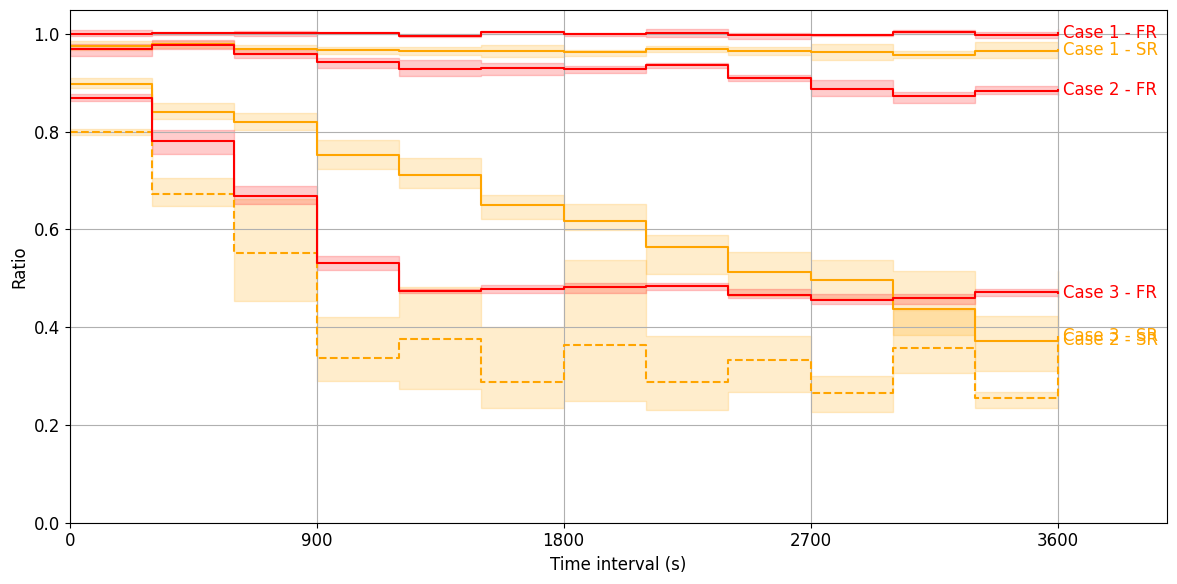

In [11]:
# plot_sr_fr_with_bands.py
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 12})

# Case labels and files
cases = [
    ("Case 1", "bands_out/case1_bands.csv"),
    ("Case 2", "bands_out/case2_bands.csv"),
    ("Case 3", "bands_out/case3_bands.csv"),
]

fig, ax = plt.subplots(figsize=(12, 6))

for label, path in cases:
    df = pd.read_csv(path).sort_values("adjusted_time")

    # Line styles (keep your convention: Case 3 dashed)
    ls = '--' if label == 'Case 3' else '-'

    # SR line + band (orange)
    ax.step(df["adjusted_time"], df["SPR_mean"], linestyle=ls, color='orange', where='post')
    ax.fill_between(df["adjusted_time"], df["SPR_p05"], df["SPR_p95"],
                    alpha=0.2, color='orange', step='post', label=None)

    # annotate SR
    ax.text(df["adjusted_time"].iloc[-1] + 20, df["SPR_mean"].iloc[-1],
            f'{label} - SR', color='orange', va='center')

    # FR line + band (red)
    ax.step(df["adjusted_time"], df["FR_mean"], linestyle='-', color='red', where='post')
    ax.fill_between(df["adjusted_time"], df["FR_p05"], df["FR_p95"],
                    alpha=0.2, color='red', step='post', label=None)

    # annotate FR
    ax.text(df["adjusted_time"].iloc[-1] + 20, df["FR_mean"].iloc[-1],
            f'{label} - FR', color='red', va='center')

# Axes/formatting (same as yours)
ax.set_xlabel('Time interval (s)')
ax.set_ylabel('Ratio')
ax.set_xlim(0, 4000)
ax.set_ylim(bottom=0)
ax.set_xticks(range(0, 3901, 900))
ax.grid(True)
plt.tight_layout()
plt.savefig('scene2-SR_FR_with_bands.pdf', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
import pandas as pd
import numpy as np

# -----------------------------
# CONFIG
# -----------------------------
csv_file = "bands_out/case3_per_seed_ratios.csv"   # your file with all seeds
time_start = 54900     # adjust (start of 1h window)
time_end   = 58200     # adjust (start+3600)
pos_start  = 0
pos_end    = 3000

# -----------------------------
# Load data
# -----------------------------
df = pd.read_csv(csv_file)

# Filter to assessment region
df_filtered = df[
    (df["interval_begin"] >= time_start) & (df["interval_begin"] < time_end) &
    (df["pos"] >= pos_start) & (df["pos"] <= pos_end)
]

# -----------------------------
# Per-seed mean SR/FR
# -----------------------------
per_seed = df_filtered.groupby("seed")[["SPR", "FR"]].mean().reset_index()

# -----------------------------
# Function: log CI
# -----------------------------
def log_ci(values, alpha=0.05):
    log_vals = np.log(values)
    mean_log = log_vals.mean()
    se_log   = log_vals.std(ddof=1) / np.sqrt(len(log_vals))
    z = 1.96  # for 95% CI
    mean_val = np.exp(mean_log)
    ci_low   = np.exp(mean_log - z*se_log)
    ci_high  = np.exp(mean_log + z*se_log)
    return mean_val, ci_low, ci_high

# -----------------------------
# Compute CIs
# -----------------------------
sr_mean, sr_low, sr_high = log_ci(per_seed["SPR"].values)
fr_mean, fr_low, fr_high = log_ci(per_seed["FR"].values)

print(f"SR = {sr_mean:.2f} [{sr_low:.2f}, {sr_high:.2f}]")
print(f"FR = {fr_mean:.2f} [{fr_low:.2f}, {fr_high:.2f}]")


SR = 0.42 [0.42, 0.42]
FR = 0.56 [0.55, 0.56]


In [22]:
import pandas as pd
import numpy as np

# Map each case to its per-seed CSV
CASE_FILES = {
    "Case 1": "bands_out/case1_per_seed_ratios.csv",
    "Case 2": "bands_out/case2_per_seed_ratios.csv",
    "Case 3": "bands_out/case3_per_seed_ratios.csv",
}

# Your assessment window (match what you used to produce the numbers!)
time_start = 54900     # adjust (start of 1h window)
time_end   = 58200     # adjust (start+3600)
pos_start  = 0
pos_end    = 3000

def log_ci(x, z=1.96):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    logx = np.log(x)
    mean_log = logx.mean()
    se_log = logx.std(ddof=1) / np.sqrt(len(logx))
    mean = np.exp(mean_log)
    lo = np.exp(mean_log - z*se_log)
    hi = np.exp(mean_log + z*se_log)
    return mean, lo, hi

def bootstrap_ci(x, B=5000, alpha=0.05, seed=123):
    rng = np.random.default_rng(seed)
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    N = len(x)
    boots = []
    for _ in range(B):
        idx = rng.integers(0, N, N)
        boots.append(np.mean(x[idx]))
    lo = np.percentile(boots, 100*alpha/2)
    hi = np.percentile(boots, 100*(1-alpha/2))
    return np.mean(x), lo, hi


rows = []
for case, path in CASE_FILES.items():
    df = pd.read_csv(path)
    df = df[(df["interval_begin"] >= TIME_START) & (df["interval_begin"] < TIME_END) &
            (df["pos"] >= POS_START) & (df["pos"] <= POS_END)]

    # one SR/FR per seed (space-time mean within the window)
    per_seed = df.groupby("seed")[["SPR","FR"]].mean().reset_index()

    sr_m, sr_lo, sr_hi = bootstrap_ci(per_seed["SPR"].values)
    fr_m, fr_lo, fr_hi = bootstrap_ci(per_seed["FR"].values)

    rows.append({
        "case": case,
        "N": len(per_seed),
        "SR": f"{sr_m:.2f} [{sr_lo:.2f}, {sr_hi:.2f}]",
        "FR": f"{fr_m:.2f} [{fr_lo:.2f}, {fr_hi:.2f}]",
    })

out = pd.DataFrame(rows)
print(out.to_string(index=False))

# Optional: print LaTeX-friendly lines
for r in rows:
    print(f"{r['case']}: SR = {r['SR']}; FR = {r['FR']} (N={r['N']}).")


  case  N                SR                FR
Case 1  5 0.99 [0.99, 0.99] 1.00 [1.00, 1.00]
Case 2  5 0.92 [0.91, 0.92] 0.98 [0.98, 0.98]
Case 3  5 0.81 [0.80, 0.81] 0.86 [0.85, 0.86]
Case 1: SR = 0.99 [0.99, 0.99]; FR = 1.00 [1.00, 1.00] (N=5).
Case 2: SR = 0.92 [0.91, 0.92]; FR = 0.98 [0.98, 0.98] (N=5).
Case 3: SR = 0.81 [0.80, 0.81]; FR = 0.86 [0.85, 0.86] (N=5).
